# 01 - Exploratory Data Analysis
Framingham Heart Study: predict `TenYearCHD` (10-year coronary heart disease).

In [1]:
import sys; sys.path.append('..')
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from src.data_preprocessing import load_raw, clean
from src.config import TARGET, FIG_DIR
df = load_raw(); print(df.shape); df.head()

(4240, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## Missing values & class balance

In [2]:
print(df.isna().sum()[df.isna().sum()>0])
print('\nPositive rate: %.3f' % df[TARGET].mean())
df = clean(df)

education     105
cigsPerDay     29
BPMeds         53
totChol        50
BMI            19
heartRate       1
glucose       388
dtype: int64

Positive rate: 0.152


## Incidence by subgroup (cf. the Stanford paper's subgroup exploration)

In [3]:
from src.features import add_age_group
d = add_age_group(df)
print((d.groupby(d.male.map({1:'Male',0:'Female'}))[TARGET].mean()*100).round(1))
print((d.groupby('age_group')[TARGET].mean()*100).round(1))

male
Female    12.4
Male      18.8
Name: TenYearCHD, dtype: float64
age_group
<45       6.4
45-54    14.9
55-64    23.2
65+      37.1
Name: TenYearCHD, dtype: float64


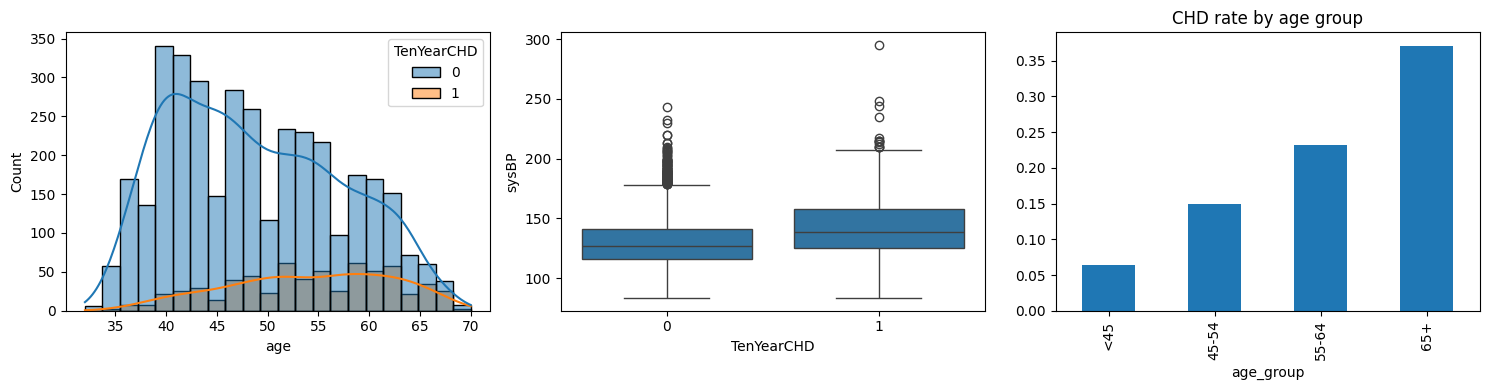

In [4]:
fig, ax = plt.subplots(1,3, figsize=(15,4))
sns.histplot(data=df, x='age', hue=TARGET, kde=True, ax=ax[0])
sns.boxplot(data=df, x=TARGET, y='sysBP', ax=ax[1])
d.groupby('age_group')[TARGET].mean().plot.bar(ax=ax[2], title='CHD rate by age group')
plt.tight_layout(); plt.savefig(FIG_DIR/'eda_overview.png', dpi=150); plt.show()

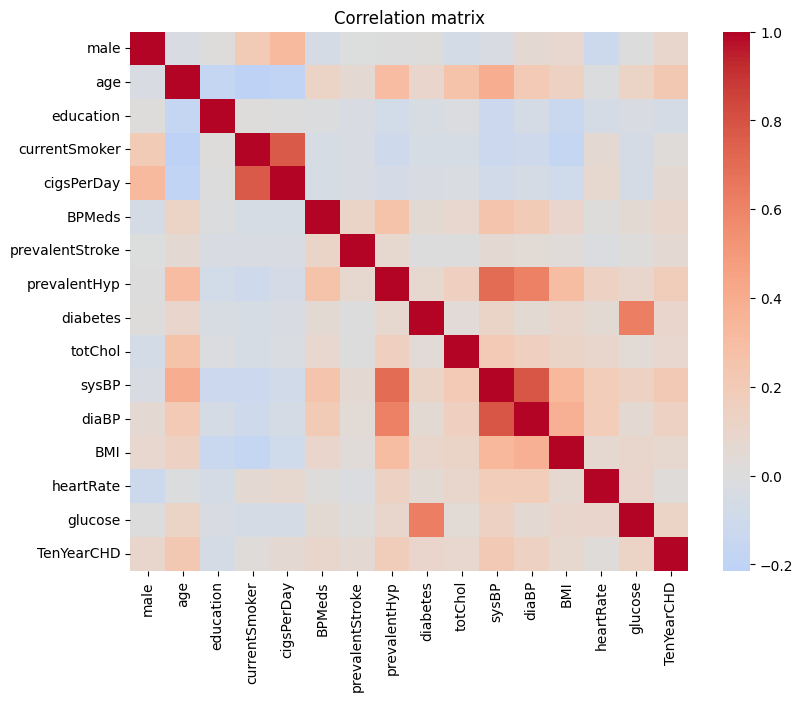

In [5]:
plt.figure(figsize=(9,7)); sns.heatmap(df.corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation matrix'); plt.savefig(FIG_DIR/'eda_corr.png', dpi=150, bbox_inches='tight'); plt.show()

**Takeaways:** ~15% positive class (imbalanced), `glucose` has the most missing values (~9%), and age is the strongest driver; men have a higher incidence than women.